In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

plt.style.use("seaborn-v0_8")
pd.set_option("display.max_columns", None)

In [2]:
DATA_PATH = "data/UNSW_NB15_training-set.csv"

RANDOM_STATE = 42
VAL_SIZE = 0.2
PERCENTILE = 98

In [3]:
df = pd.read_csv(DATA_PATH, encoding="latin1")
print("Original shape:", df.shape)

Original shape: (175341, 45)


In [4]:
if "label" not in df.columns:
    raise ValueError("Column 'label' not found in dataset.")

df["target"] = df["label"].astype(int)

print(df["target"].value_counts())

target
1    119341
0     56000
Name: count, dtype: int64


In [5]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

feature_cols = [
    c for c in numeric_cols
    if c.lower() != "target"
    and "label" not in c.lower()
    and "attack" not in c.lower()
]

print("All numeric columns:", len(numeric_cols))
print("Feature columns used for modeling:", len(feature_cols))
print("Removed columns:", [c for c in numeric_cols if c not in feature_cols])

All numeric columns: 42
Feature columns used for modeling: 40
Removed columns: ['label', 'target']


In [6]:
df[feature_cols] = df[feature_cols].replace([np.inf, -np.inf], np.nan)

before_drop = df.shape[0]
df = df.dropna(subset=feature_cols).reset_index(drop=True)
after_drop = df.shape[0]

print(f"Rows removed during cleaning: {before_drop - after_drop}")
print("Cleaned shape:", df.shape)

Rows removed during cleaning: 0
Cleaned shape: (175341, 46)


In [7]:
X = df[feature_cols].copy()
y = df["target"].values.astype(int)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Class distribution:", np.bincount(y))

X shape: (175341, 40)
y shape: (175341,)
Class distribution: [ 56000 119341]


In [8]:
normal_mask = (y == 0)

X_normal = X.loc[normal_mask].copy()

X_train, X_val = train_test_split(
    X_normal,
    test_size=VAL_SIZE,
    random_state=RANDOM_STATE,
    shuffle=True
)

X_test = X.copy()
y_test = y.copy()

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)

X_train shape: (44800, 40)
X_val shape: (11200, 40)
X_test shape: (175341, 40)


In [9]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = np.nan_to_num(X_train_scaled, nan=0.0, posinf=0.0, neginf=0.0)
X_val_scaled = np.nan_to_num(X_val_scaled, nan=0.0, posinf=0.0, neginf=0.0)
X_test_scaled = np.nan_to_num(X_test_scaled, nan=0.0, posinf=0.0, neginf=0.0)

In [10]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

EPOCHS = 10
BATCH_SIZE = 256
input_dim = X_train_scaled.shape[1]
latent_dim = 8

class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        epsilon = tf.random.normal(shape=tf.shape(z_mean))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

inputs = keras.Input(shape=(input_dim,))
h = layers.Dense(64, activation="relu")(inputs)
h = layers.Dense(32, activation="relu")(h)
z_mean = layers.Dense(latent_dim)(h)
z_log_var = layers.Dense(latent_dim)(h)
z = Sampling()([z_mean, z_log_var])

encoder = keras.Model(inputs, [z_mean, z_log_var, z], name="encoder")

latent_inputs = keras.Input(shape=(latent_dim,))
h = layers.Dense(32, activation="relu")(latent_inputs)
h = layers.Dense(64, activation="relu")(h)
outputs = layers.Dense(input_dim, activation="linear")(h)
decoder = keras.Model(latent_inputs, outputs, name="decoder")

class VAE(keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder

    def train_step(self, data):
        if isinstance(data, tuple):
            data = data[0]
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)
            reconstruction_loss = tf.reduce_mean(tf.square(data - reconstruction))
            kl_loss = -0.5 * tf.reduce_mean(
                1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var)
            )
            total_loss = reconstruction_loss + kl_loss
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        return {
            "loss": total_loss,
            "recon_loss": reconstruction_loss,
            "kl_loss": kl_loss,
        }

model = VAE(encoder, decoder)
model.compile(optimizer=keras.optimizers.Adam())

history = model.fit(
    X_train_scaled,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    verbose=1
)


Epoch 1/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - kl_loss: 0.0226 - loss: 0.9592 - recon_loss: 0.9367
Epoch 2/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - kl_loss: 0.0530 - loss: 0.8966 - recon_loss: 0.8436
Epoch 3/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - kl_loss: 0.0888 - loss: 0.9729 - recon_loss: 0.8841
Epoch 4/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - kl_loss: 0.0807 - loss: 0.6530 - recon_loss: 0.5723
Epoch 5/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - kl_loss: 0.1189 - loss: 0.8439 - recon_loss: 0.7250
Epoch 6/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - kl_loss: 0.1480 - loss: 0.6792 - recon_loss: 0.5312
Epoch 7/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - kl_loss: 0.1339 - loss: 0.5984 - recon_loss: 0.4645
Epoch 8/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - kl_loss: 0.1947 - loss: 0.7037 - recon_loss: 0.5090
Epoch 9/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - kl_loss: 0.2127 - loss: 0.7648 - recon_loss: 0.5521
Epoch 10/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 7

In [11]:
_, _, z_val = encoder.predict(X_val_scaled, verbose=0)
X_val_pred = decoder.predict(z_val, verbose=0)
scores_val = np.mean((X_val_scaled - X_val_pred) ** 2, axis=1)

_, _, z_test = encoder.predict(X_test_scaled, verbose=0)
X_test_pred = decoder.predict(z_test, verbose=0)
scores_test = np.mean((X_test_scaled - X_test_pred) ** 2, axis=1)

print("Validation score range:", scores_val.min(), scores_val.max())
print("Test score range:", scores_test.min(), scores_test.max())

Validation score range: 0.01431806085978784 28.114829940782755
Test score range: 0.013095403917324375 14241.347338672382


In [12]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc
)

fpr, tpr, roc_thresholds = roc_curve(y_test, scores_test)
roc_auc = auc(fpr, tpr)

PERCENTILES = [99, 98, 95, 90, 85, 80, 70, 60, 50]

results = []

for p in PERCENTILES:
    threshold = np.percentile(scores_val, p)
    y_pred_p = (scores_test >= threshold).astype(int)

    acc_p = accuracy_score(y_test, y_pred_p)
    prec_p = precision_score(y_test, y_pred_p, zero_division=0)
    rec_p = recall_score(y_test, y_pred_p, zero_division=0)
    f1_p = f1_score(y_test, y_pred_p, zero_division=0)

    results.append({
        "Percentil": p,
        "Threshold": threshold,
        "Precision": prec_p,
        "Recall": rec_p,
        "F1-score": f1_p,
        "Accuracy": acc_p,
        "AUC": roc_auc,
        "Predicted anomalies": int(y_pred_p.sum())
    })

results_df = pd.DataFrame(results)
results_df

,Percentil,Threshold,Precision,Recall,F1-score,Accuracy,AUC,Predicted anomalies
0,99,3.336574,0.908592,0.045810,0.087222,0.347420,0.780825,6017
1,98,2.983042,0.874423,0.065057,0.121104,0.357298,0.780825,8879
2,95,1.431874,0.913904,0.243445,0.384474,0.469462,0.780825,31790
3,90,0.781390,0.909902,0.468556,0.618576,0.606709,0.780825,61455
4,85,0.634603,0.887519,0.552400,0.680963,0.647704,0.780825,74279
5,80,0.529684,0.870008,0.629733,0.730623,0.683947,0.780825,86382
6,70,0.428920,0.835369,0.715756,0.770950,0.710530,0.780825,102253
7,60,0.345699,0.807161,0.789393,0.798178,0.728295,0.780825,116714
8,50,0.273449,0.784444,0.857333,0.819270,0.742553,0.780825,130430


In [13]:
threshold = np.percentile(scores_val, PERCENTILE)
y_pred = (scores_test >= threshold).astype(int)

print(f"Threshold (percentile={PERCENTILE}):", threshold)

Threshold (percentile=98): 2.9830415348107193


In [14]:
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
cm = confusion_matrix(y_test, y_pred)

print("=== VAE ===")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")

=== VAE ===
Accuracy : 0.3573
Precision: 0.8744
Recall   : 0.0651
F1-score : 0.1211


              precision    recall  f1-score   support

           0     0.3297    0.9801    0.4934     56000
           1     0.8744    0.0651    0.1211    119341

    accuracy                         0.3573    175341
   macro avg     0.6021    0.5226    0.3073    175341
weighted avg     0.7005    0.3573    0.2400    175341



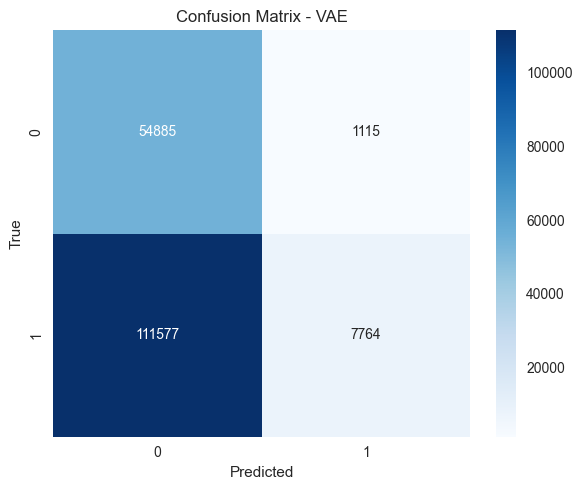

In [15]:
print(classification_report(y_test, y_pred, digits=4, zero_division=0))

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - VAE")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

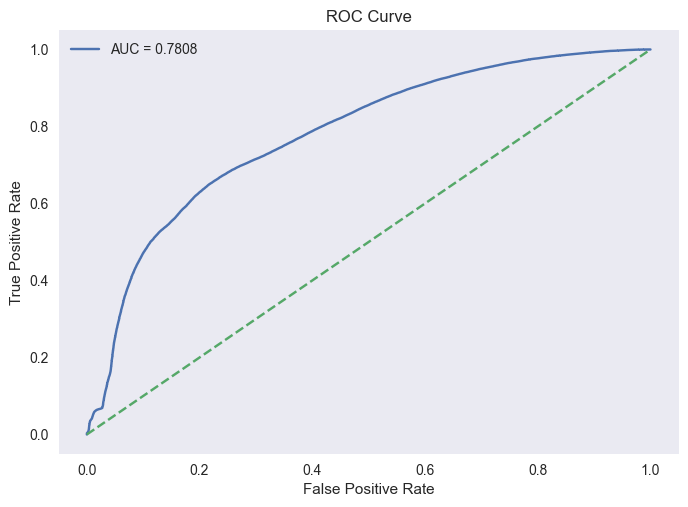

AUC: 0.7808253517531396


In [16]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, scores_test)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()

plt.show()

print("AUC:", roc_auc)